Loading ECG files: 100%|██████████| 1974/1974 [00:20<00:00, 97.84it/s] 


Total records loaded: 987
Each record has 5000 samples per lead.
Lead I data shape: (987, 5000)
Lead II data shape: (987, 5000)
Lead I scaled data range: -1.0 1.0000000000000004
Lead II scaled data range: -3.4331450094161955 3.042488619119878
Pre-training Autoencoder ...
AE Epoch [1/20] Loss: 2.5324
AE Epoch [2/20] Loss: 1.5115
AE Epoch [3/20] Loss: 0.6621
AE Epoch [4/20] Loss: 0.3941
AE Epoch [5/20] Loss: 0.2789
AE Epoch [6/20] Loss: 0.2036
AE Epoch [7/20] Loss: 0.1398
AE Epoch [8/20] Loss: 0.0824
AE Epoch [9/20] Loss: 0.0546
AE Epoch [10/20] Loss: 0.0388
AE Epoch [11/20] Loss: 0.0308
AE Epoch [12/20] Loss: 0.0242
AE Epoch [13/20] Loss: 0.0191
AE Epoch [14/20] Loss: 0.0168
AE Epoch [15/20] Loss: 0.0143
AE Epoch [16/20] Loss: 0.0112
AE Epoch [17/20] Loss: 0.0091
AE Epoch [18/20] Loss: 0.0085
AE Epoch [19/20] Loss: 0.0066
AE Epoch [20/20] Loss: 0.0093
Joint Training (Adversarial) ...
Epoch [1/20] - D Loss: 37.5172, G Loss: 23.0636
Checkpoint saved at checkpoints\checkpoint_epoch_1.pth
E

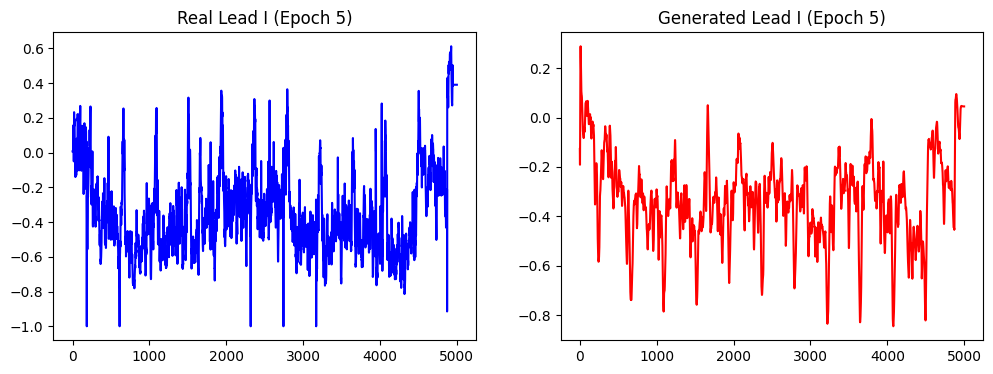

Epoch [6/20] - D Loss: 46.8262, G Loss: 31.4789
Checkpoint saved at checkpoints\checkpoint_epoch_6.pth
Epoch [7/20] - D Loss: 42.8382, G Loss: 32.8575
Checkpoint saved at checkpoints\checkpoint_epoch_7.pth
Epoch [8/20] - D Loss: 29.7094, G Loss: 39.9287
Checkpoint saved at checkpoints\checkpoint_epoch_8.pth
Epoch [9/20] - D Loss: 35.6545, G Loss: 26.5145
Checkpoint saved at checkpoints\checkpoint_epoch_9.pth
Epoch [10/20] - D Loss: 31.1133, G Loss: 25.1204
Checkpoint saved at checkpoints\checkpoint_epoch_10.pth


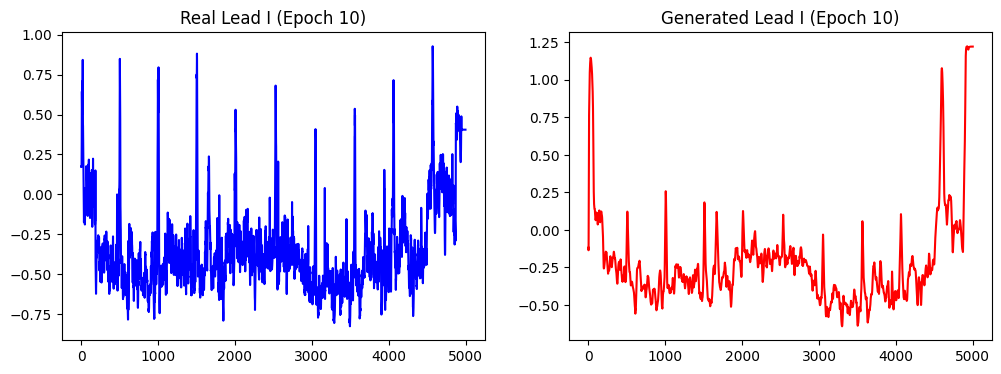

Epoch [11/20] - D Loss: 25.4396, G Loss: 36.0812
Checkpoint saved at checkpoints\checkpoint_epoch_11.pth
Epoch [12/20] - D Loss: 21.1186, G Loss: 48.9943
Checkpoint saved at checkpoints\checkpoint_epoch_12.pth
Epoch [13/20] - D Loss: 33.5127, G Loss: 25.8953
Checkpoint saved at checkpoints\checkpoint_epoch_13.pth
Epoch [14/20] - D Loss: 40.4924, G Loss: 24.2972
Checkpoint saved at checkpoints\checkpoint_epoch_14.pth
Epoch [15/20] - D Loss: 44.3724, G Loss: 25.5152
Checkpoint saved at checkpoints\checkpoint_epoch_15.pth


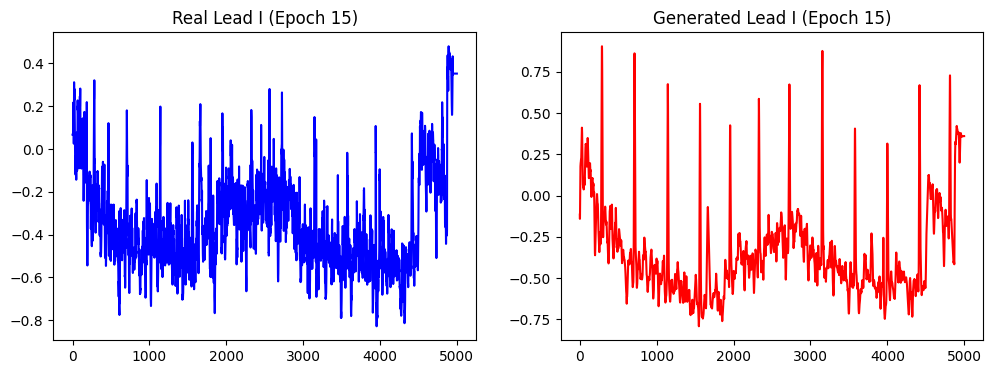

Epoch [16/20] - D Loss: 44.5713, G Loss: 25.7230
Checkpoint saved at checkpoints\checkpoint_epoch_16.pth
Epoch [17/20] - D Loss: 45.4379, G Loss: 21.6582
Checkpoint saved at checkpoints\checkpoint_epoch_17.pth
Epoch [18/20] - D Loss: 42.4950, G Loss: 25.4621
Checkpoint saved at checkpoints\checkpoint_epoch_18.pth
Epoch [19/20] - D Loss: 40.2855, G Loss: 27.6502
Checkpoint saved at checkpoints\checkpoint_epoch_19.pth
Epoch [20/20] - D Loss: 44.4474, G Loss: 22.2030
Checkpoint saved at checkpoints\checkpoint_epoch_20.pth


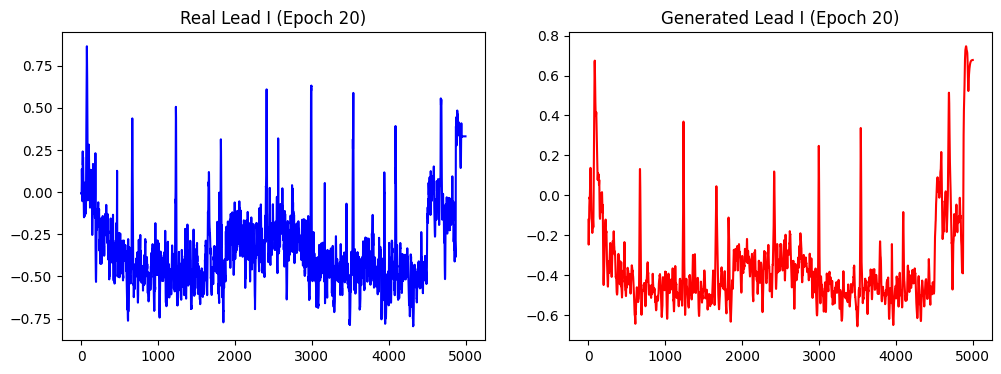

In [2]:
import os
import wfdb
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# ========================
# 1. Data Loading & Preprocessing
# ========================

# Define the path to your dataset directory
DATA_DIR = "C:/Users/M2-Winterfell/Downloads/electrocardiography-dataset-1.0.3/records500/00000"

def load_ecg_leads(file_path):
    try:
        record = wfdb.rdrecord(file_path)
        # Extract Lead I and Lead II (assuming they are the first two leads)
        lead_I = record.p_signal[:, 0]
        lead_II = record.p_signal[:, 1]
        return lead_I, lead_II
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

def load_first_n_ecg_data(data_dir, n=1000):
    all_lead_I = []
    all_lead_II = []
    count = 0
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc="Loading ECG files"):
            if file.endswith("_hr.dat"):
                if count >= n:
                    break
                base_filename = file.replace("_hr.dat", "_hr")
                record_path = os.path.join(root, base_filename)
                lead_I, lead_II = load_ecg_leads(record_path)
                if lead_I is not None and lead_II is not None:
                    all_lead_I.append(lead_I)
                    all_lead_II.append(lead_II)
                    count += 1
                else:
                    print(f"Skipping record: {base_filename}")
        if count >= n:
            break
    if all_lead_I and all_lead_II:
        all_lead_I = np.array(all_lead_I)  # shape: (num_records, samples)
        all_lead_II = np.array(all_lead_II)
    else:
        all_lead_I = np.array([])
        all_lead_II = np.array([])
    return all_lead_I, all_lead_II

# Load ECG data (first 1000 records)
lead_I_data, lead_II_data = load_first_n_ecg_data(DATA_DIR, n=1000)

if lead_I_data.size > 0 and lead_II_data.size > 0:
    print(f"Total records loaded: {lead_I_data.shape[0]}")
    print(f"Each record has {lead_I_data.shape[1]} samples per lead.")
    print("Lead I data shape:", lead_I_data.shape)
    print("Lead II data shape:", lead_II_data.shape)
else:
    print("No data was loaded.")

# Normalize using MinMaxScaler (range -1 to 1)
scaler = MinMaxScaler(feature_range=(-1, 1))
if lead_I_data.size > 0 and lead_II_data.size > 0:
    lead_I_scaled = scaler.fit_transform(lead_I_data)
    lead_II_scaled = scaler.transform(lead_II_data)
    print("Lead I scaled data range:", lead_I_scaled.min(), lead_I_scaled.max())
    print("Lead II scaled data range:", lead_II_scaled.min(), lead_II_scaled.max())
else:
    print("Skipping normalization since no data was loaded.")

# Convert data to PyTorch tensors and add a channel dimension.
# (Shape: [num_records, seq_len, 1])
lead_I_tensor = torch.tensor(lead_I_scaled, dtype=torch.float32)
lead_II_tensor = torch.tensor(lead_II_scaled, dtype=torch.float32)
lead_I_tensor = lead_I_tensor.unsqueeze(-1)
lead_II_tensor = lead_II_tensor.unsqueeze(-1)

# ========================
# 2. Define TimeGAN-Inspired Architecture (using LSTMs)
# ========================

# Hyperparameters
seq_len = lead_I_tensor.shape[1]  # e.g., 5000 samples per record
input_dim = 1    # one channel (ECG amplitude)
hidden_dim = 64  # latent dimension
num_layers = 1

# Encoder: maps real lead I to a latent representation
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(Encoder, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
    def forward(self, x):
        h, _ = self.lstm(x)  # h: [batch, seq_len, hidden_dim]
        return h

# Recovery: reconstructs ECG signal from latent representation
class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super(Recovery, self).__init__()
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, h):
        out, _ = self.lstm(h)  # out: [batch, seq_len, hidden_dim]
        x_tilde = self.fc(out) # x_tilde: [batch, seq_len, output_dim]
        return x_tilde

# Generator: produces latent representation from conditional input (lead II)
class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(Generator, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
    def forward(self, c):
        h_fake, _ = self.lstm(c)  # [batch, seq_len, hidden_dim]
        return h_fake

# Supervisor: refines the latent representation
class Supervisor(nn.Module):
    def __init__(self, hidden_dim, hidden_dim_out, num_layers):
        super(Supervisor, self).__init__()
        self.lstm = nn.LSTM(hidden_dim, hidden_dim_out, num_layers, batch_first=True)
        
    def forward(self, h):
        h_sup, _ = self.lstm(h)
        return h_sup

# Discriminator: distinguishes between real and synthetic latent sequences.
class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super(Discriminator, self).__init__()
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, h):
        out, _ = self.lstm(h)  # [batch, seq_len, hidden_dim]
        last_out = out[:, -1, :]  # take the last output for classification
        logits = self.fc(last_out)  # [batch, 1]
        prob = torch.sigmoid(logits)
        return prob

# Instantiate modules
encoder = Encoder(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers)
recovery = Recovery(hidden_dim=hidden_dim, output_dim=input_dim, num_layers=num_layers)
generator = Generator(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers)
supervisor = Supervisor(hidden_dim=hidden_dim, hidden_dim_out=hidden_dim, num_layers=num_layers)
discriminator = Discriminator(hidden_dim=hidden_dim, num_layers=num_layers)

# Move models to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder.to(device)
recovery.to(device)
generator.to(device)
supervisor.to(device)
discriminator.to(device)

# ========================
# 3. Define Optimizers, Learning Rate Schedulers, and Loss Functions
# ========================

mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss()

# Set lower learning rates
lr_ae = 0.0005
lr_gen = 0.0005
lr_disc = 0.0005

ae_params = list(encoder.parameters()) + list(recovery.parameters())
opt_ae = optim.Adam(ae_params, lr=lr_ae)
opt_gen = optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=lr_gen)
opt_disc = optim.Adam(discriminator.parameters(), lr=lr_disc)

# Learning rate schedulers (decay every 5 epochs by 0.95)
scheduler_ae = StepLR(opt_ae, step_size=5, gamma=0.95)
scheduler_gen = StepLR(opt_gen, step_size=5, gamma=0.95)
scheduler_disc = StepLR(opt_disc, step_size=5, gamma=0.95)

# Training parameters
pretrain_ae_epochs = 20  # as observed from your output
joint_train_epochs = 20
batch_size = 32

dataset_size = lead_I_tensor.shape[0]
indices = np.arange(dataset_size)

# Create a folder to save checkpoints
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# ========================
# 4. Training
# ========================

# --- Phase 1: Pre-train the Autoencoder (Encoder + Recovery) ---
print("Pre-training Autoencoder ...")
for epoch in range(pretrain_ae_epochs):
    perm = np.random.permutation(dataset_size)
    epoch_loss = 0
    for i in range(0, dataset_size, batch_size):
        batch_idx = perm[i:i+batch_size]
        x_real = lead_I_tensor[batch_idx].to(device)  # [batch, seq_len, 1]
        opt_ae.zero_grad()
        h = encoder(x_real)
        x_recon = recovery(h)
        loss_ae = mse_loss(x_recon, x_real)
        loss_ae.backward()
        opt_ae.step()
        epoch_loss += loss_ae.item()
    scheduler_ae.step()
    print(f"AE Epoch [{epoch+1}/{pretrain_ae_epochs}] Loss: {epoch_loss:.4f}")

# --- Phase 2: Joint Training of Generator (+Supervisor) and Discriminator ---
print("Joint Training (Adversarial) ...")
real_label_val = 0.9
fake_label_val = 0.1

for epoch in range(joint_train_epochs):
    perm = np.random.permutation(dataset_size)
    epoch_d_loss = 0
    epoch_g_loss = 0
    for i in range(0, dataset_size, batch_size):
        batch_idx = perm[i:i+batch_size]
        # Get paired batch: lead I (target) and lead II (condition)
        x_real = lead_I_tensor[batch_idx].to(device)   # target signal
        c = lead_II_tensor[batch_idx].to(device)         # condition signal
        bsize = x_real.size(0)
        
        # --- Train Discriminator ---
        h_real = encoder(x_real).detach()  # real latent representation
        h_fake_raw = generator(c)          # from condition input
        h_fake = supervisor(h_fake_raw)    # refined latent representation
        h_fake_detached = h_fake.detach()
        
        d_real = discriminator(h_real)
        d_fake = discriminator(h_fake_detached)
        
        real_labels = torch.full((bsize, 1), real_label_val, device=device)
        fake_labels = torch.full((bsize, 1), fake_label_val, device=device)
        
        loss_d_real = bce_loss(d_real, real_labels)
        loss_d_fake = bce_loss(d_fake, fake_labels)
        loss_d = loss_d_real + loss_d_fake
        
        opt_disc.zero_grad()
        loss_d.backward()
        opt_disc.step()
        
        # --- Train Generator (+ Supervisor) ---
        h_fake_raw = generator(c)
        h_fake = supervisor(h_fake_raw)
        x_fake = recovery(h_fake)
        
        d_fake_for_gen = discriminator(h_fake)
        loss_adv = bce_loss(d_fake_for_gen, real_labels)
        loss_recon = mse_loss(x_fake, x_real)
        loss_gen = loss_adv + loss_recon
        
        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()
        
        epoch_d_loss += loss_d.item()
        epoch_g_loss += loss_gen.item()
    
    scheduler_gen.step()
    scheduler_disc.step()
    
    print(f"Epoch [{epoch+1}/{joint_train_epochs}] - D Loss: {epoch_d_loss:.4f}, G Loss: {epoch_g_loss:.4f}")
    
    # Save checkpoint for this epoch
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch+1,
        'encoder_state_dict': encoder.state_dict(),
        'recovery_state_dict': recovery.state_dict(),
        'generator_state_dict': generator.state_dict(),
        'supervisor_state_dict': supervisor.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'opt_ae_state_dict': opt_ae.state_dict(),
        'opt_gen_state_dict': opt_gen.state_dict(),
        'opt_disc_state_dict': opt_disc.state_dict(),
        'scheduler_ae_state_dict': scheduler_ae.state_dict(),
        'scheduler_gen_state_dict': scheduler_gen.state_dict(),
        'scheduler_disc_state_dict': scheduler_disc.state_dict()
    }, checkpoint_path)
    print(f"Checkpoint saved at {checkpoint_path}")
    
    # Optionally, every 5 epochs, generate a sample plot
    if (epoch + 1) % 5 == 0:
        rand_idx = np.random.randint(0, dataset_size)
        x_real_sample = lead_I_tensor[rand_idx].unsqueeze(0).to(device)
        c_sample = lead_II_tensor[rand_idx].unsqueeze(0).to(device)
        with torch.no_grad():
            h_fake_sample = supervisor(generator(c_sample))
            x_fake_sample = recovery(h_fake_sample)
        x_real_np = x_real_sample.squeeze().cpu().numpy()
        x_fake_np = x_fake_sample.squeeze().cpu().numpy()
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(x_real_np, color='blue')
        plt.title(f"Real Lead I (Epoch {epoch+1})")
        plt.subplot(1, 2, 2)
        plt.plot(x_fake_np, color='red')
        plt.title(f"Generated Lead I (Epoch {epoch+1})")
        plt.show()


In [19]:

# ========================
# 5. (Optional) Load a specific checkpoint before generation
# ========================
# Uncomment and set the desired epoch to load the corresponding checkpoint
checkpoint_to_load = "checkpoints/checkpoint_epoch_13.pth"  # change the epoch as needed
checkpoint = torch.load(checkpoint_to_load, map_location=device)
encoder.load_state_dict(checkpoint['encoder_state_dict'])
recovery.load_state_dict(checkpoint['recovery_state_dict'])
generator.load_state_dict(checkpoint['generator_state_dict'])
supervisor.load_state_dict(checkpoint['supervisor_state_dict'])
discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}.")

Loaded checkpoint from epoch 13.


C:\Users\M2-Winterfell\AppData\Local\Temp\ipykernel_17492\2028813255.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_to_load, map_loca

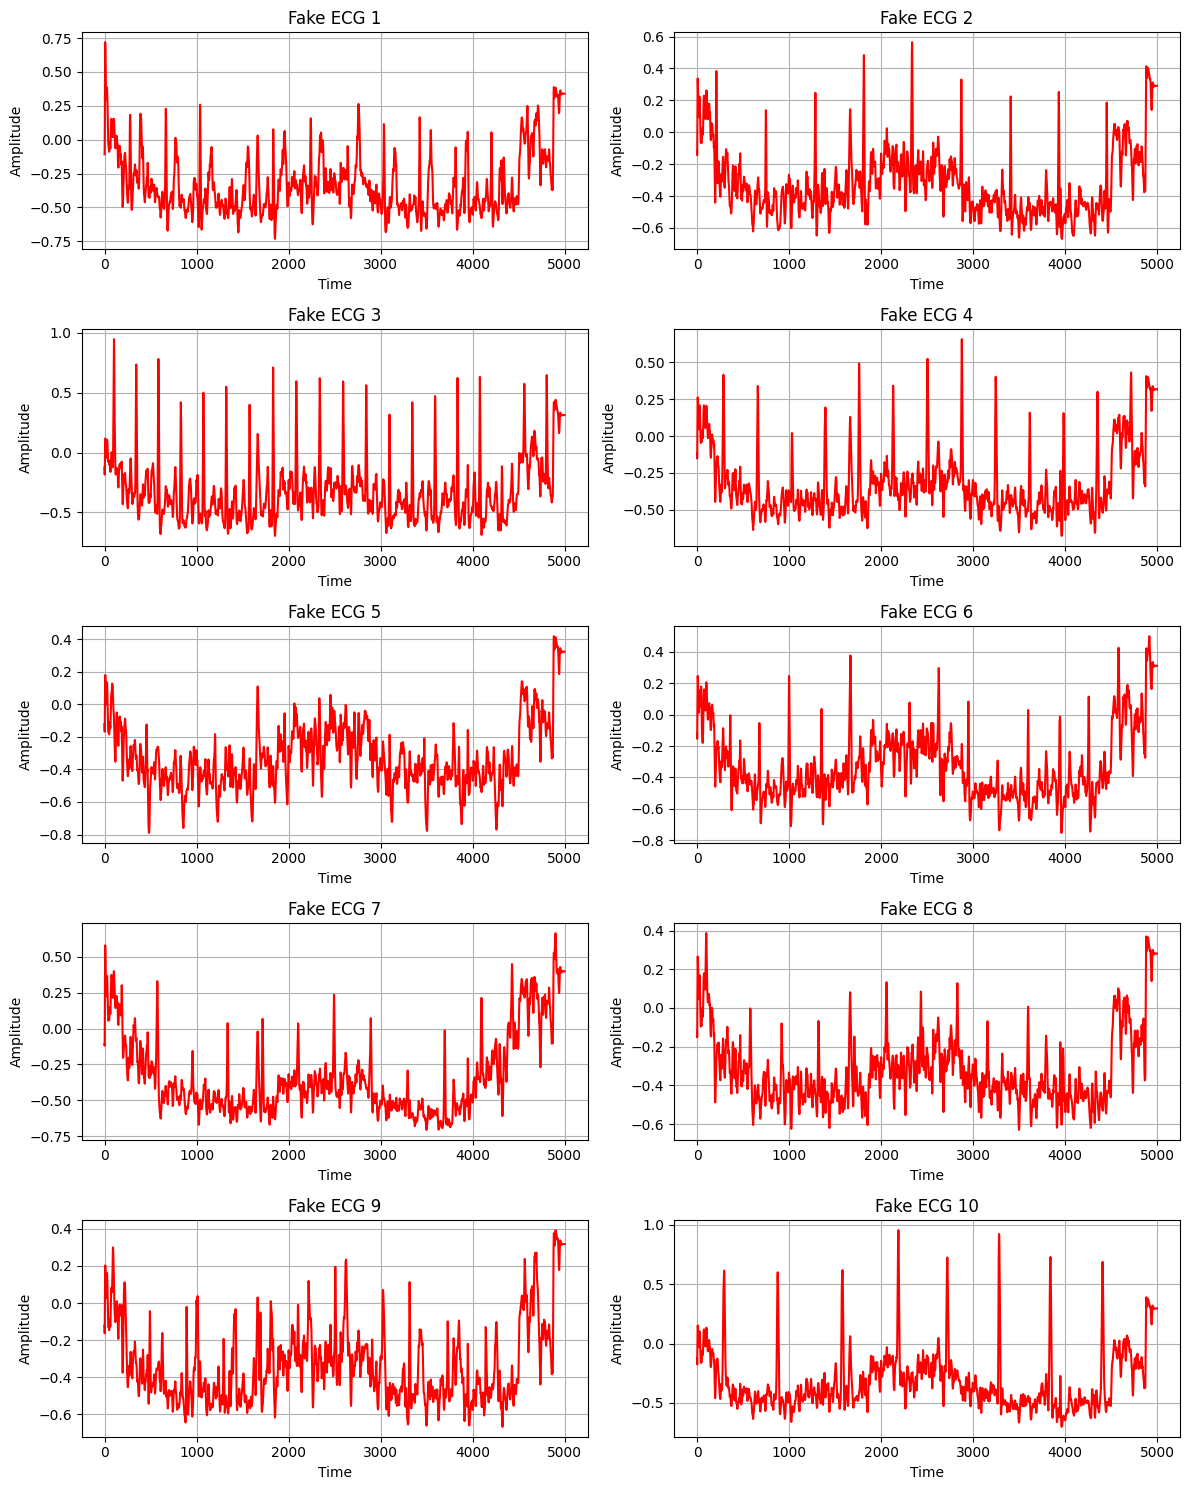

In [21]:
# ========================
# 6. Generate and Save Fake ECG Signals Using the (current or loaded) model
# ========================

save_path = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/torch_timegan_fake"
os.makedirs(save_path, exist_ok=True)

num_fake = 1000
for i in range(num_fake):
    rand_idx = np.random.randint(0, dataset_size)
    c_sample = lead_II_tensor[rand_idx].unsqueeze(0).to(device)
    with torch.no_grad():
        h_fake = supervisor(generator(c_sample))
        x_fake = recovery(h_fake)
    fake_signal = x_fake.squeeze().cpu().numpy()
    np.savetxt(os.path.join(save_path, f"{i+1}.asc"), fake_signal)

# Plot the first 10 generated fake ECG signals
plt.figure(figsize=(12, 15))
for i in range(10):
    fake_signal = np.loadtxt(os.path.join(save_path, f"{i+1}.asc"))
    plt.subplot(5, 2, i+1)
    plt.plot(fake_signal, color='red')
    plt.title(f"Fake ECG {i+1}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()